# Q1 - Deep Learning Regression on "Wine Quality" Dataset

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers



## Load & Explore the Data

In [2]:
# Load both red and white wine datasets
df_red   = pd.read_csv("data/winequality-red.csv",   sep=";")
df_white = pd.read_csv("data/winequality-white.csv", sep=";")

# Add wine_type column: 0 = red, 1 = white
df_red["wine_type"]   = 0
df_white["wine_type"] = 1

# Combine into one dataframe
df = pd.concat([df_red, df_white], ignore_index=True)

print("Red samples:  ", len(df_red))
print("White samples:", len(df_white))
print("Total samples:", len(df))
print("First 5 rows:")
df.head()


Red samples:   1599
White samples: 4898
Total samples: 6497
First 5 rows:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0


In [3]:
# Check for missing values and data types
print("Missing values:\n", df.isnull().sum())
print("\nData types:\n", df.dtypes)
print("\nBasic statistics:")
df.describe()


Missing values:
 fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
wine_type               0
dtype: int64

Data types:
 fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
wine_type                 int64
dtype: object

Basic statistics:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378,0.753886
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255,0.430779
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000,0.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000,1.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000,1.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000,1.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000,1.000000


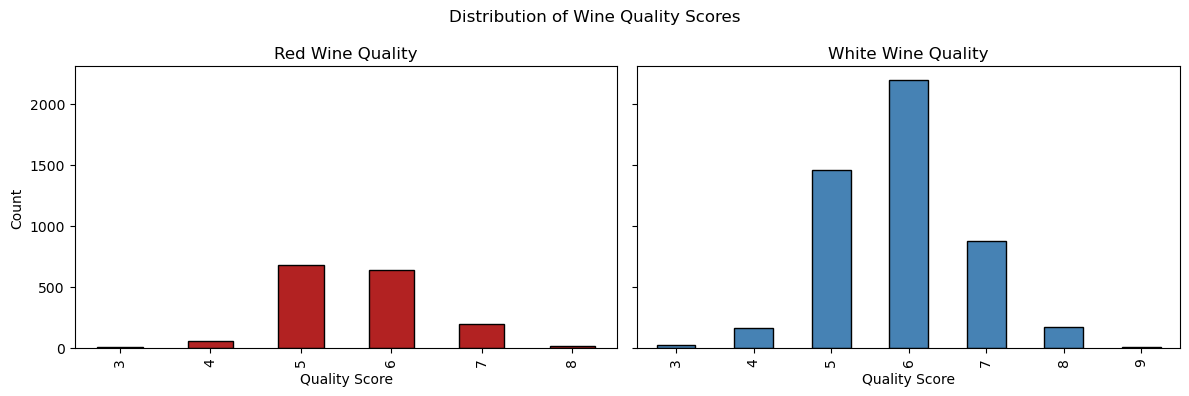

In [4]:
# Distribution of quality scores by wine type
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

df[df["wine_type"]==0]["quality"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color="firebrick", edgecolor="black")
axes[0].set_title("Red Wine Quality")
axes[0].set_xlabel("Quality Score")
axes[0].set_ylabel("Count")

df[df["wine_type"]==1]["quality"].value_counts().sort_index().plot(
    kind="bar", ax=axes[1], color="steelblue", edgecolor="black")
axes[1].set_title("White Wine Quality")
axes[1].set_xlabel("Quality Score")

plt.suptitle("Distribution of Wine Quality Scores")
plt.tight_layout()
plt.show()


## Preprocess

In [5]:
# Separate features and target
# Now 12 features: 11 physicochemical + wine_type
X = df.drop(columns=["quality"]).values
y = df["quality"].values

# Train / validation / test split  (70 / 15 / 15)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print(f"Train:      {X_train.shape}")
print(f"Validation: {X_val.shape}")
print(f"Test:       {X_test.shape}")


Train:      (4547, 12)
Validation: (975, 12)
Test:       (975, 12)


In [6]:
# Scale features using StandardScaler (fit ONLY on training data)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print("Feature mean (should be ~0):", X_train.mean(axis=0).round(4))
print("Feature std  (should be ~1):", X_train.std(axis=0).round(4))


Feature mean (should be ~0): [-0. -0.  0. -0.  0.  0.  0.  0.  0. -0. -0. -0.]
Feature std  (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## Build the Neural Network

In [7]:
tf.random.set_seed(42)

model = keras.Sequential([
    layers.Input(shape=(12,)),           # 11 physicochemical features + wine_type
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1)                      # linear output for regression
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,457 (13.50 KB)

 Trainable params: 3,457 (13.50 KB)

 Non-trainable params: 0 (0.00 B)

## Compile & Train

In [8]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/200
143/143 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 9.6502 - mae: 2.3838 - val_loss: 1.7582 - val_mae: 0.9938
Epoch 2/200
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.3543 - mae: 0.8980 - val_loss: 1.1792 - val_mae: 0.8328
Epoch 3/200
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9813 - mae: 0.7673 - val_loss: 0.9088 - val_mae: 0.7340
Epoch 4/200
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7706 - mae: 0.6806 - val_loss: 0.7344 - val_mae: 0.6617
Epoch 5/200
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6445 - mae: 0.6230 - val_loss: 0.6249 - val_mae: 0.6084
Epoch 6/200
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5723 - mae: 0.5860 - val_loss: 0.5630 - val_mae: 0.5760
Epoch 7/200
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5336 - mae: 0.5645 - val_loss: 0.5283 - val_mae: 0.5589
Epoch 8/200
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5119 - mae: 0.5529 - val_loss: 0.5110 - val_mae: 0.5506
Epoch 9/200
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/

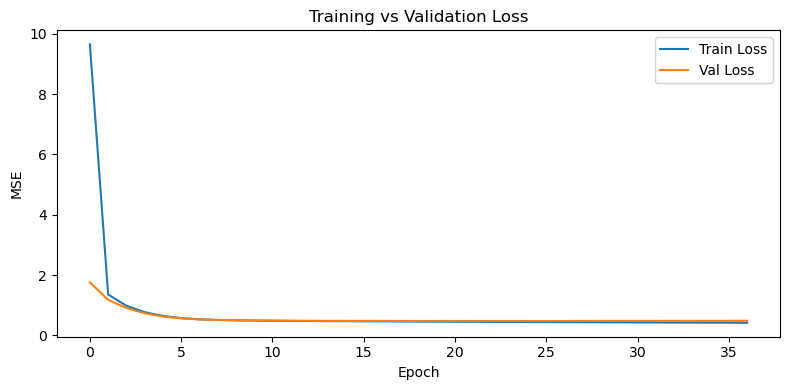

In [9]:
# Plot training vs validation loss
plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Training vs Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()


## Evaluate on Test Set

In [10]:
# Evaluate on the held-out test set
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)
print(f"Test MSE: {test_loss:.4f}")
print(f"Test MAE: {test_mae:.4f}")
print(f"Test RMSE: {test_loss**0.5:.4f}")


Test MSE: 0.4755
Test MAE: 0.5397
Test RMSE: 0.6895


31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


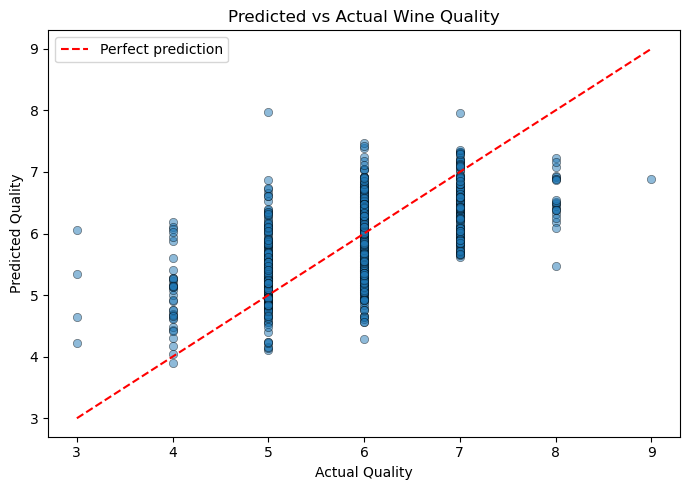

In [11]:
# Predicted vs Actual quality scores
y_pred = model.predict(X_test).flatten()

plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, alpha=0.5, edgecolors="k", linewidths=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", label="Perfect prediction")
plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")
plt.title("Predicted vs Actual Wine Quality")
plt.legend()
plt.tight_layout()
plt.show()
